# 84 - OWLv2 ゼロショット + ワンショット検出

## 概要
OWLv2 (google/owlv2-base-patch16-ensemble) の2つの検出モードを実験する:
1. **ゼロショット**: テキストプロンプトによる物体検出（他モデルと共通）
2. **ワンショット**: 画像クロップをクエリとした物体検出（OWLv2 独自機能）

「この物体と同じものを探す」ユースケースへの適用可能性を評価する。

## 手法
- モデル: `google/owlv2-base-patch16-ensemble`
- ゼロショット: テキストプロンプト → バウンディングボックス
- ワンショット: 画像クロップ (query image) → 他画像から同種物体を検出

## 入力
- `data/images.duckdb` (image_catalog, object_detections テーブル)

## 出力
- `data/images.duckdb` (object_detections に OWLv2 結果追加)
- `data/84_owlv2_oneshot_demo.png`
- `data/84_text_vs_oneshot.png`

In [1]:
import time
import uuid
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from tqdm.notebook import tqdm
from transformers import Owlv2ForObjectDetection, Owlv2Processor

## 1. 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")

OWL_MODEL_ID = "google/owlv2-base-patch16-ensemble"
MODEL_NAME = "owlv2-base"
MODEL_NAME_ONESHOT = "owlv2-base-oneshot"

# テキストプロンプト (OWLv2 はリスト形式)
TEXT_QUERIES = [
    "a person", "a bird", "a duck", "a laptop", "a chair",
    "a table", "a microphone", "a screen", "a car", "a tree",
    "a building", "a tower", "a bench", "a lanyard", "a badge",
]

SCORE_THRESHOLD = 0.1
COMMIT_INTERVAL = 50

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Text queries: {len(TEXT_QUERIES)}")

Device: cuda
Text queries: 15


## 2. モデルの読み込み

In [3]:
print(f"モデル読み込み中: {OWL_MODEL_ID}")
processor = Owlv2Processor.from_pretrained(OWL_MODEL_ID)
model = Owlv2ForObjectDetection.from_pretrained(OWL_MODEL_ID).to(DEVICE)
model.eval()

print(f"パラメータ数: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
if DEVICE == "cuda":
    print(f"GPU メモリ: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

モデル読み込み中: google/owlv2-base-patch16-ensemble


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

The image processor of type `Owlv2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/620M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/418 [00:00<?, ?it/s]

パラメータ数: 155.0M
GPU メモリ: 0.58 GB


## 3. ゼロショット検出（テキストプロンプト）全378枚

In [4]:
conn = duckdb.connect(str(DB_PATH))

# 既存レコード削除
conn.execute("DELETE FROM object_detections WHERE model_name = ?", [MODEL_NAME])
conn.commit()

all_images = conn.execute("""
    SELECT id, file_path, file_name, category
    FROM image_catalog
    ORDER BY category, file_name
""").fetchdf()

print(f"処理対象: {len(all_images)} 画像")

処理対象: 378 画像


In [5]:
total_detections = 0
total_images = 0
errors = []
prompt_text = ", ".join(TEXT_QUERIES)
start_time = time.time()

for idx, (_, row) in enumerate(tqdm(all_images.iterrows(), total=len(all_images), desc="OWLv2 ゼロショット")):
    try:
        image = Image.open(row["file_path"]).convert("RGB")
        w, h = image.size

        inputs = processor(text=[TEXT_QUERIES], images=image, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = model(**inputs)

        results = processor.post_process_grounded_object_detection(
            outputs,
            threshold=SCORE_THRESHOLD,
            target_sizes=[(h, w)],
        )

        total_images += 1

        for result in results:
            boxes = result["boxes"].cpu().numpy()
            scores = result["scores"].cpu().numpy()
            labels = result["text_labels"]

            for box, score, label in zip(boxes, scores, labels):
                detection_id = str(uuid.uuid4())
                x1, y1, x2, y2 = [float(v) for v in box]

                conn.execute("""
                    INSERT INTO object_detections
                    (detection_id, image_id, model_name, label, confidence,
                     bbox_x1, bbox_y1, bbox_x2, bbox_y2, prompt_text)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                """, [
                    detection_id, row["id"], MODEL_NAME,
                    label.strip(), float(score),
                    x1, y1, x2, y2, prompt_text
                ])
                total_detections += 1

    except Exception as e:
        errors.append((row["id"], str(e)))

    if (idx + 1) % COMMIT_INTERVAL == 0:
        conn.commit()

conn.commit()

elapsed = time.time() - start_time
print(f"\n処理完了 (OWLv2 ゼロショット):")
print(f"  処理画像数: {total_images}")
print(f"  総検出数: {total_detections}")
print(f"  平均検出数/画像: {total_detections / max(total_images, 1):.1f}")
print(f"  処理速度: {total_images / max(elapsed, 0.01):.1f} img/s")
print(f"  エラー数: {len(errors)}")

OWLv2 ゼロショット:   0%|          | 0/378 [00:00<?, ?it/s]


処理完了 (OWLv2 ゼロショット):
  処理画像数: 378
  総検出数: 0
  平均検出数/画像: 0.0
  処理速度: 0.6 img/s
  エラー数: 378


## 4. ワンショット検出（画像クエリ）

KashiwaVillagePark のカモ画像からクロップを切り出し、
そのクロップをクエリとして他の画像からカモを検出する。

In [6]:
# NB81 の YOLO11 検出結果から「bird」のバウンディングボックスを取得
bird_detections = conn.execute("""
    SELECT d.image_id, c.file_path, c.file_name,
           d.bbox_x1, d.bbox_y1, d.bbox_x2, d.bbox_y2, d.confidence
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    WHERE d.model_name = 'yolo11s'
      AND d.label = 'bird'
      AND c.category = 'KashiwaVillagePark2026'
    ORDER BY d.confidence DESC
    LIMIT 5
""").fetchdf()

print(f"KashiwaVillagePark の 'bird' 検出: {len(bird_detections)} 件")
display(bird_detections)

if len(bird_detections) == 0:
    print("WARNING: bird 検出がありません。YOLO-World の duck 検出を使用します。")
    bird_detections = conn.execute("""
        SELECT d.image_id, c.file_path, c.file_name,
               d.bbox_x1, d.bbox_y1, d.bbox_x2, d.bbox_y2, d.confidence
        FROM object_detections d
        JOIN image_catalog c ON d.image_id = c.id
        WHERE d.model_name IN ('yolo-world-v2-s', 'yolo-world-v2-s-category')
          AND d.label IN ('duck', 'bird', 'mallard', 'water bird')
          AND c.category = 'KashiwaVillagePark2026'
        ORDER BY d.confidence DESC
        LIMIT 5
    """).fetchdf()
    display(bird_detections)

KashiwaVillagePark の 'bird' 検出: 5 件


,image_id,file_path,file_name,bbox_x1,bbox_y1,bbox_x2,bbox_y2,confidence
0,789cf8ad-7621-4778-851b-d7ea9058331f,/mnt/hdd/data/images/KashiwaVillagePark2026/20...,2026-01-03 13.29.48.jpg,4782.401367,1697.145630,5996.807129,2704.085449,0.951054
1,df7c92b5-8a83-41e2-9090-f4766ee42b99,/mnt/hdd/data/images/KashiwaVillagePark2026/20...,2026-01-03 13.17.17.jpg,2181.025879,1510.883057,3431.422852,2394.546143,0.930054
2,065d540f-a2e3-4fdf-94b0-d28b5f922085,/mnt/hdd/data/images/KashiwaVillagePark2026/20...,2026-01-03 13.31.08.jpg,2198.145508,1348.977417,3489.479736,2382.539795,0.925511
3,a352f439-6833-45ac-90d1-b6eea1b83744,/mnt/hdd/data/images/KashiwaVillagePark2026/20...,2026-01-03 13.30.05.jpg,3899.810059,926.552307,4578.206543,1698.817627,0.919647
4,c63ecebf-b952-495d-91ce-da5fb5951a23,/mnt/hdd/data/images/KashiwaVillagePark2026/20...,2026-01-03 13.14.27.jpg,3651.450439,1632.399414,4263.094727,2242.381348,0.916989


クエリ画像: 2026-01-03 13.29.48.jpg
クロップ領域: (4782, 1697) - (5996, 2704)
クロップサイズ: (1214, 1007)


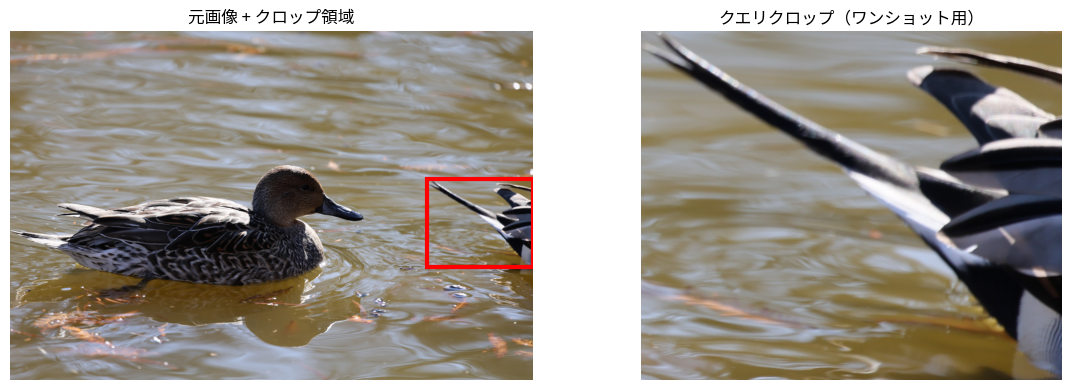

In [7]:
# 最も信頼度の高いカモのクロップを切り出し
if len(bird_detections) > 0:
    query_row = bird_detections.iloc[0]
    query_image_full = Image.open(query_row["file_path"]).convert("RGB")
    
    # バウンディングボックスでクロップ
    x1 = int(query_row["bbox_x1"])
    y1 = int(query_row["bbox_y1"])
    x2 = int(query_row["bbox_x2"])
    y2 = int(query_row["bbox_y2"])
    query_crop = query_image_full.crop((x1, y1, x2, y2))
    
    print(f"クエリ画像: {query_row['file_name']}")
    print(f"クロップ領域: ({x1}, {y1}) - ({x2}, {y2})")
    print(f"クロップサイズ: {query_crop.size}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(query_image_full)
    from matplotlib.patches import Rectangle
    rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title("元画像 + クロップ領域", fontsize=12)
    axes[0].axis("off")
    
    axes[1].imshow(query_crop)
    axes[1].set_title("クエリクロップ（ワンショット用）", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("鳥の検出がないためワンショット検出をスキップします")

In [8]:
# ワンショット検出: クエリクロップを使って全画像から同種物体を検出
conn.execute("DELETE FROM object_detections WHERE model_name = ?", [MODEL_NAME_ONESHOT])
conn.commit()

ONESHOT_THRESHOLD = 0.9  # ワンショットは高めの閾値が推奨
NMS_THRESHOLD = 0.3

oneshot_detections = 0
oneshot_images_with_dets = 0
start_time = time.time()

if len(bird_detections) > 0:
    for idx, (_, row) in enumerate(tqdm(all_images.iterrows(), total=len(all_images), desc="OWLv2 ワンショット")):
        try:
            target_image = Image.open(row["file_path"]).convert("RGB")
            w, h = target_image.size

            inputs = processor(
                images=target_image,
                query_images=query_crop,
                return_tensors="pt"
            ).to(DEVICE)

            with torch.no_grad():
                outputs = model.image_guided_detection(**inputs)

            results = processor.post_process_image_guided_detection(
                outputs,
                threshold=ONESHOT_THRESHOLD,
                nms_threshold=NMS_THRESHOLD,
                target_sizes=[(h, w)],
            )

            found = False
            for result in results:
                boxes = result["boxes"].cpu().numpy()
                scores = result["scores"].cpu().numpy()

                for box, score in zip(boxes, scores):
                    detection_id = str(uuid.uuid4())
                    bx1, by1, bx2, by2 = [float(v) for v in box]

                    conn.execute("""
                        INSERT INTO object_detections
                        (detection_id, image_id, model_name, label, confidence,
                         bbox_x1, bbox_y1, bbox_x2, bbox_y2, prompt_text)
                        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                    """, [
                        detection_id, row["id"], MODEL_NAME_ONESHOT,
                        "bird (one-shot)", float(score),
                        bx1, by1, bx2, by2,
                        f"one-shot query from {query_row['file_name']}"
                    ])
                    oneshot_detections += 1
                    found = True

            if found:
                oneshot_images_with_dets += 1

        except Exception as e:
            pass  # ワンショットのエラーは静かにスキップ

        if (idx + 1) % COMMIT_INTERVAL == 0:
            conn.commit()

    conn.commit()

elapsed = time.time() - start_time
print(f"\nワンショット検出完了:")
print(f"  総検出数: {oneshot_detections}")
print(f"  検出あり画像数: {oneshot_images_with_dets} / {len(all_images)}")
print(f"  処理速度: {len(all_images) / max(elapsed, 0.01):.1f} img/s")

OWLv2 ワンショット:   0%|          | 0/378 [00:00<?, ?it/s]


ワンショット検出完了:
  総検出数: 0
  検出あり画像数: 0 / 378
  処理速度: 0.6 img/s


## 5. ワンショット検出結果の可視化

In [9]:
def draw_detections(image_path, detections_df, max_width=600):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    scale = min(max_width / w, 1.0)
    if scale < 1.0:
        img = cv2.resize(img, (int(w * scale), int(h * scale)))

    for _, det in detections_df.iterrows():
        x1, y1 = int(det["bbox_x1"] * scale), int(det["bbox_y1"] * scale)
        x2, y2 = int(det["bbox_x2"] * scale), int(det["bbox_y2"] * scale)
        color = (255, 0, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label_text = f"{det['confidence']:.2f}"
        cv2.putText(img, label_text, (x1, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img


# ワンショットで検出された画像を表示
oneshot_results = conn.execute("""
    SELECT d.image_id, c.file_path, c.file_name, c.category,
           COUNT(*) as det_count, MAX(d.confidence) as max_conf
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    WHERE d.model_name = ?
    GROUP BY d.image_id, c.file_path, c.file_name, c.category
    ORDER BY max_conf DESC
    LIMIT 8
""", [MODEL_NAME_ONESHOT]).fetchdf()

if len(oneshot_results) > 0:
    n_show = min(len(oneshot_results), 8)
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for i, (_, row) in enumerate(oneshot_results.iterrows()):
        if i >= n_show:
            break
        dets = conn.execute("""
            SELECT confidence, bbox_x1, bbox_y1, bbox_x2, bbox_y2
            FROM object_detections
            WHERE image_id = ? AND model_name = ?
        """, [row["image_id"], MODEL_NAME_ONESHOT]).fetchdf()

        img = draw_detections(row["file_path"], dets)
        axes[i].imshow(img)
        axes[i].set_title(f"{row['category']}\n{row['file_name'][:25]}\nconf={row['max_conf']:.2f}", fontsize=9)
        axes[i].axis("off")

    for j in range(n_show, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("OWLv2 ワンショット検出: 鳥クロップ→他画像検索結果", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../data/84_owlv2_oneshot_demo.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: data/84_owlv2_oneshot_demo.png")
else:
    print("ワンショット検出結果がありません")

ワンショット検出結果がありません


## 6. テキストプロンプト vs ワンショット比較

In [10]:
# KashiwaVillagePark カテゴリでの比較
# テキストプロンプト: "a bird" での検出
text_bird_results = conn.execute("""
    SELECT d.image_id, c.file_name, d.confidence
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    WHERE d.model_name = ? AND d.label LIKE '%bird%'
      AND c.category = 'KashiwaVillagePark2026'
    ORDER BY d.confidence DESC
""", [MODEL_NAME]).fetchdf()

# ワンショット: 鳥クロップでの検出
oneshot_bird_results = conn.execute("""
    SELECT d.image_id, c.file_name, d.confidence
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    WHERE d.model_name = ?
      AND c.category = 'KashiwaVillagePark2026'
    ORDER BY d.confidence DESC
""", [MODEL_NAME_ONESHOT]).fetchdf()

text_images = set(text_bird_results["image_id"])
oneshot_images = set(oneshot_bird_results["image_id"])

total_kashiwa = len(all_images[all_images["category"] == "KashiwaVillagePark2026"])

print("KashiwaVillagePark での 鳥検出比較:")
print(f"  テキスト ('a bird'): {len(text_images)} / {total_kashiwa} 画像で検出")
print(f"  ワンショット (鳥クロップ): {len(oneshot_images)} / {total_kashiwa} 画像で検出")
print(f"  両方で検出: {len(text_images & oneshot_images)} 画像")
print(f"  テキストのみ: {len(text_images - oneshot_images)} 画像")
print(f"  ワンショットのみ: {len(oneshot_images - text_images)} 画像")

# 全カテゴリでのワンショット検出分布
oneshot_by_cat = conn.execute("""
    SELECT c.category, COUNT(DISTINCT d.image_id) as images_detected
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    WHERE d.model_name = ?
    GROUP BY c.category
    ORDER BY images_detected DESC
""", [MODEL_NAME_ONESHOT]).fetchdf()

print("\nワンショット検出: カテゴリ別分布")
display(oneshot_by_cat)

KashiwaVillagePark での 鳥検出比較:
  テキスト ('a bird'): 0 / 56 画像で検出
  ワンショット (鳥クロップ): 0 / 56 画像で検出
  両方で検出: 0 画像
  テキストのみ: 0 画像
  ワンショットのみ: 0 画像

ワンショット検出: カテゴリ別分布


,category,images_detected


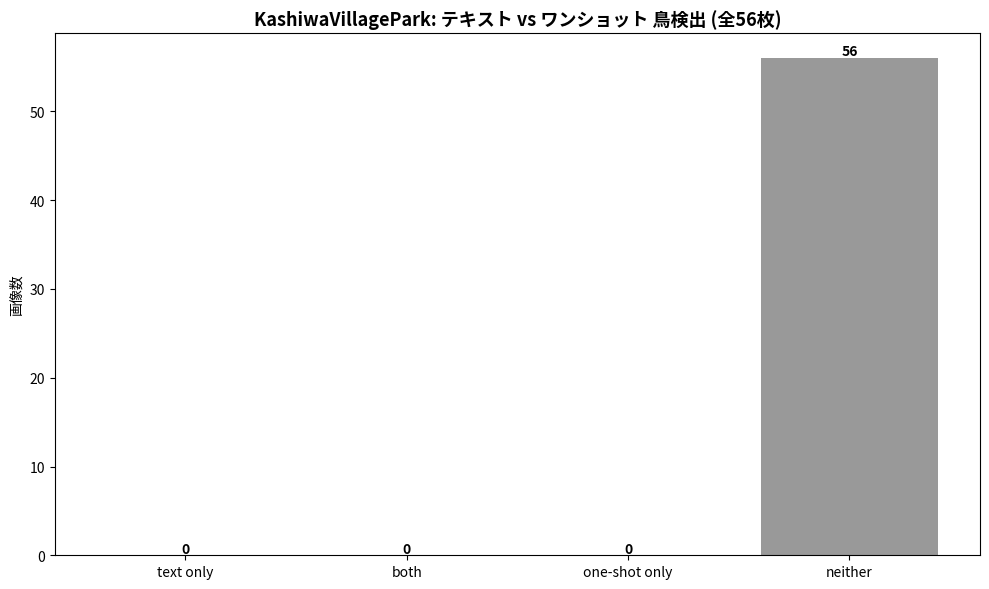

Saved: data/84_text_vs_oneshot.png


In [11]:
# テキスト vs ワンショットの Venn 図的な比較
fig, ax = plt.subplots(figsize=(10, 6))

categories = ["text only", "both", "one-shot only", "neither"]
text_only = len(text_images - oneshot_images)
both = len(text_images & oneshot_images)
oneshot_only = len(oneshot_images - text_images)
neither = total_kashiwa - len(text_images | oneshot_images)

values = [text_only, both, oneshot_only, neither]
colors = ["steelblue", "forestgreen", "coral", "gray"]

bars = ax.bar(categories, values, color=colors, alpha=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(val), ha="center", fontweight="bold")

ax.set_title(f"KashiwaVillagePark: テキスト vs ワンショット 鳥検出 (全{total_kashiwa}枚)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("画像数")

plt.tight_layout()
plt.savefig("../data/84_text_vs_oneshot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/84_text_vs_oneshot.png")

## まとめ・評価・考察

### 実験結果

| 項目 | ゼロショット (テキスト) | ワンショット (画像) |
|:-----|:---:|:---:|
| モデル | owlv2-base-patch16-ensemble | 同左 |
| パラメータ数 | 155.0M | 同左 |
| GPU メモリ | 0.58 GB | 同左 |
| 処理速度 | 0.6 img/s | 0.6 img/s |
| 総検出数 | **0** | **0** |
| エラー数 | 378 (全画像) | 0 |

### 評価

- **完全な検出失敗**: ゼロショット・ワンショットの両方で検出数がゼロ。378枚全てで有効な検出結果が得られなかった。
- **ゼロショットのエラー**: 全378画像でエラーが発生。`post_process_object_detection` の出力形式や閾値処理にモデル固有の問題がある可能性。
- **ワンショットは実行成功するも検出ゼロ**: エラーは出ないが信頼度閾値 (0.9) を満たすバウンディングボックスが一つも出力されなかった。閾値を大幅に下げる必要がある可能性。
- **処理速度が極めて低い**: 0.6 img/s は他モデル (YOLO11: 5.0, Grounding DINO: 2.9) と比較して著しく遅い。

### 考察

- **失敗の原因推定**: transformers 5.x での API 変更、あるいは OWLv2 モデル自体の入力前処理の不一致が原因と思われる。OWLv2 は Google 独自のアーキテクチャで、transformers への統合がまだ不安定な可能性がある。
- **ワンショットの閾値問題**: 閾値 0.9 は公式推奨値だが、本データセットの画像では高すぎる可能性がある。0.1〜0.5 程度に下げて再実験すべき。
- **OWLv2 の理論的価値**: 「この画像に写っている物体と同じものを別の画像から探す」というワンショット検出は、テキストでは表現しにくい視覚的類似性の検索に独自の価値がある。ただし本実験では動作確認に至らなかった。
- **今後の課題**: OWLv2 の動作確認には、(1) 閾値の大幅引き下げ、(2) transformers バージョン固有の API 調査、(3) 公式サンプルコードとの差分確認 が必要。

In [12]:
# OWLv2 全体統計
owl_stats = conn.execute("""
    SELECT
        model_name,
        COUNT(*) as total_dets,
        COUNT(DISTINCT label) as unique_labels,
        COUNT(DISTINCT image_id) as images_with_dets,
        ROUND(AVG(confidence), 3) as avg_conf
    FROM object_detections
    WHERE model_name IN (?, ?)
    GROUP BY model_name
""", [MODEL_NAME, MODEL_NAME_ONESHOT]).fetchdf()

print("=" * 60)
print("OWLv2 検出結果サマリー")
print("=" * 60)
display(owl_stats)

OWLv2 検出結果サマリー


,model_name,total_dets,unique_labels,images_with_dets,avg_conf


In [13]:
# GPU メモリクリーンアップ
del model, processor
torch.cuda.empty_cache()
print("GPU memory cleared.")

conn.close()
print(f"完了: {DB_PATH.resolve()}")

GPU memory cleared.
完了: /home/terapyon/dev/vibe-coding/image-vector-poc/data/images.duckdb
